# Proyek Klasifikasi Gambar: [Food-101]
- **Nama:** [Ajeng Nina Riski]
- **Email:** [ajengnina12@gmail.com]
- **ID Dicoding:** [mc525d5x0112]

## Import Semua Packages/Library yang Digunakan

In [30]:
# 📦 Library Standar
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# 📁 Manipulasi File dan Gambar
from PIL import Image
import pathlib
from glob import glob
import random

# 📊 Machine Learning & Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# 🔍 Evaluasi
from sklearn.metrics import classification_report, confusion_matrix

# Install tensorflowjs if not already installed
!pip install tensorflowjs

# 💾 Ekspor Model
import tensorflowjs as tfjs  # Untuk TFJS
import tensorflow.lite as tflite  # Untuk TFLite

## Data Preparation

### Data Loading

In [31]:
# Tentukan kelas yang ingin dipilih (misalnya 3 kelas)
selected_classes = ['apple_pie', 'beef_carpaccio', 'beef_tartare']

# Tentukan path dataset yang sudah diekstrak
dataset_path = '/content/drive/MyDrive/Colab Notebooks/food101/images'

# Membaca gambar dari folder dan pilih hanya yang ada di selected_classes
image_paths = []
labels = []

for label in selected_classes:
    class_path = os.path.join(dataset_path, label)
    for img_path in pathlib.Path(class_path).rglob('*.jpg'):  # atau format lain seperti .png
        image_paths.append(str(img_path))
        labels.append(label)

# Menampilkan beberapa sample gambar
print(f"Jumlah gambar yang dipilih: {len(image_paths)}")

Jumlah gambar yang dipilih: 2100


In [32]:
# Membagi data menjadi train, validation, dan test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(image_paths, labels, test_size=0.3, stratify=labels, random_state=42)
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)

# Menampilkan informasi split data
print(f"Train set: {len(train_paths)} gambar")
print(f"Validation set: {len(val_paths)} gambar")
print(f"Test set: {len(test_paths)} gambar")

Train set: 1470 gambar
Validation set: 315 gambar
Test set: 315 gambar


In [53]:
# Buat ImageDataGenerator untuk preprocessing (resize, rescale, augmentasi)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


val_datagen = ImageDataGenerator(rescale=1./255)  # Hanya rescale untuk validation dan test

# Function untuk membaca dan menghasilkan data dalam format batch
def load_data(image_paths, labels, batch_size=32):
    # Membaca gambar dan label ke dalam array
    data = []
    for img_path, label in zip(image_paths, labels):
        img = Image.open(img_path).resize((224, 224))  # Resize gambar ke 224x224 (atau ukuran lain yang diinginkan)
        img = np.array(img)  # Ubah gambar menjadi array numpy
        data.append(img)

    data = np.array(data)
    return data, labels

# Load data untuk train, val, dan test
X_train, y_train = load_data(train_paths, train_labels)
X_val, y_val = load_data(val_paths, val_labels)
X_test, y_test = load_data(test_paths, test_labels)

# Mengubah label menjadi angka (misalnya, integer encoding untuk label)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

In [54]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Path asli dan path baru
# original_path = 'food101/images' # Updated to correct path
original_path = '/content/drive/MyDrive/Colab Notebooks/food101/images' # This assumes your dataset is in the same location as defined earlier in the code
base_path = 'data_split'
class_names = ['apple_pie', 'beef_carpaccio', 'beef_tartare']

# Buat folder baru
for split in ['train', 'val', 'test']:
    for class_name in class_names:
        os.makedirs(os.path.join(base_path, split, class_name), exist_ok=True)

# Pindahkan gambar ke train/val/test
for class_name in class_names:
    img_dir = os.path.join(original_path, class_name)
    images = os.listdir(img_dir)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for img_name in train_imgs:
        shutil.copy(os.path.join(img_dir, img_name), os.path.join(base_path, 'train', class_name, img_name))
    for img_name in val_imgs:
        shutil.copy(os.path.join(img_dir, img_name), os.path.join(base_path, 'val', class_name, img_name))
    for img_name in test_imgs:
        shutil.copy(os.path.join(img_dir, img_name), os.path.join(base_path, 'test', class_name, img_name))

print("Gambar berhasil dipindahkan ke struktur folder train/val/test.")

Gambar berhasil dipindahkan ke struktur folder train/val/test.


### Data Preprocessing

#### Split Dataset

In [62]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # bisa juga True setelah beberapa epoch

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Untuk validasi dan testing: hanya rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Buat generator
train_generator = train_datagen.flow_from_directory(
    'data_split/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    'data_split/val',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    'data_split/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # penting kalau nanti ingin evaluasi/inference
)

<ipython-input-62-806bc820fbd3>:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1470 images belonging to 3 classes.
Found 315 images belonging to 3 classes.
Found 315 images belonging to 3 classes.


## Modelling

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define img_height and img_width
img_height = 150
img_width = 150
num_classes = 3  # Assuming 3 classes: apple_pie, beef_carpaccio, beef_tartare


model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [65]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [66]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=3, min_lr=1e-6, verbose=1)

# Tambahkan ke callbacks
callbacks = [early_stop, checkpoint, reduce_lr]

In [67]:
import tensorflow as tf

# Enable eager execution explicitly
tf.config.run_functions_eagerly(True)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5883 - loss: 1.3780
Epoch 1: val_accuracy improved from -inf to 0.85397, saving model to best_model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.5905 - loss: 1.3675 - val_accuracy: 0.8540 - val_loss: 0.3979
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8119 - loss: 0.4945
Epoch 2: val_accuracy improved from 0.85397 to 0.87302, saving model to best_model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.8117 - loss: 0.4944 - val_accuracy: 0.8730 - val_loss: 0.3358
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8256 - loss: 0.4182
Epoch 3: val_accuracy did not improve from 0.87302
46/46 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.8254 - loss: 0.4185 - val_accuracy: 0.8349 - val_loss: 0.3939
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8209 - loss: 0.4167
Epoch 4: val_accuracy improved from 0.87302 to 0.88889, saving model to best_model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.8213 - loss: 0.4164 - val_accuracy: 0.8889 - val_loss: 0.3200
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8508 - loss: 0.3873
Epoch 5: val_accuracy did not improve from 0.88889
46/46 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8506 - loss: 0.3874 - val_accuracy: 0.8698 - val_loss: 0.3288
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8667 - loss: 0.3625
Epoch 6: val_accuracy did not improve from 0.88889
46/46 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.8666 - loss: 0.3622 - val_accuracy: 0.8825 - val_loss: 0.2941
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8636 - loss: 0.3474
Epoch 7: val_accuracy did not improve from 0.88889
46/46 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8635 - loss: 0.3474 - val_accuracy: 0.8762 - val_loss: 0.3182
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8839 - loss: 0.3164
Epoch 8: val_accuracy improved from 0.88889 to 0.89

46/46 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8838 - loss: 0.3164 - val_accuracy: 0.8952 - val_loss: 0.3109
Epoch 9/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8838 - loss: 0.2919
Epoch 9: val_accuracy did not improve from 0.89524
46/46 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8837 - loss: 0.2921 - val_accuracy: 0.8762 - val_loss: 0.3476
Epoch 10/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8859 - loss: 0.2879
Epoch 10: val_accuracy did not improve from 0.89524
46/46 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.8858 - loss: 0.2883 - val_accuracy: 0.8698 - val_loss: 0.3363
Epoch 11/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8900 - loss: 0.2871
Epoch 11: val_accuracy did not improve from 0.89524
46/46 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8900 - loss: 0.2872 - val_accuracy: 0.8825 - val_loss: 0.3290


## Evaluasi dan Visualisasi

In [68]:
from keras.models import load_model

# Load model terbaik
model = load_model('best_model.h5')

# Evaluasi di test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 876ms/step - accuracy: 0.8649 - loss: 0.2920
Test accuracy: 0.8635, Test loss: 0.3404


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


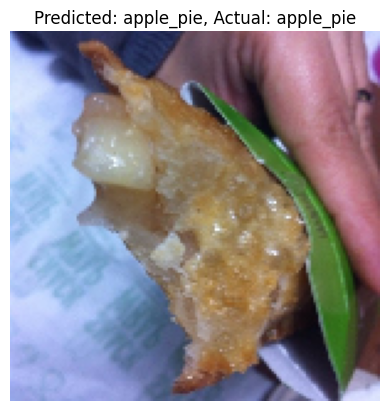

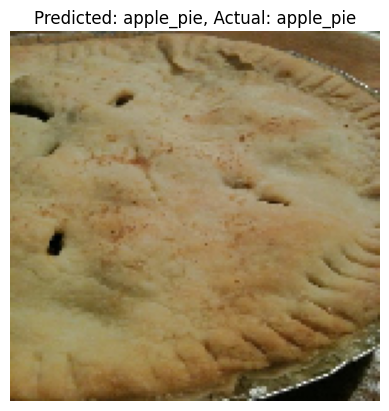

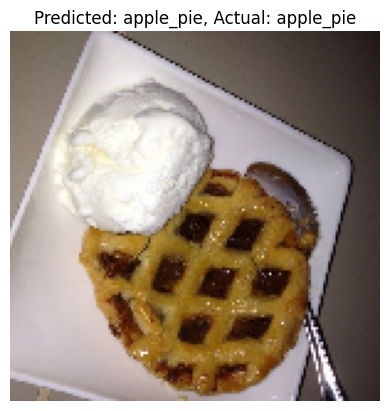

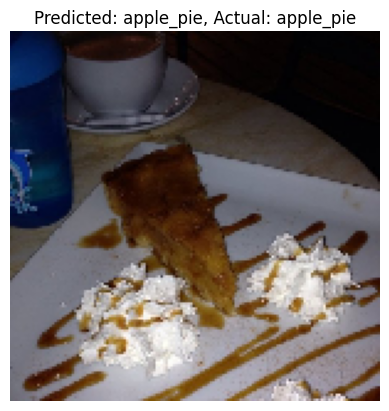

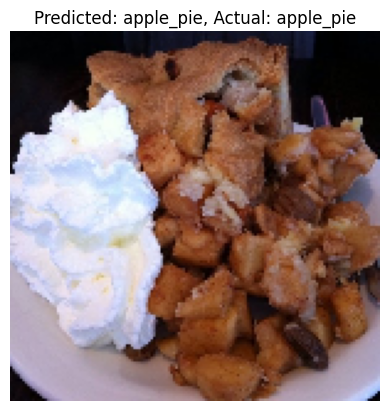

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Ambil batch gambar dari test set
x_test, y_test = next(test_generator)

# Prediksi
preds = model.predict(x_test)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Tampilkan beberapa gambar dengan prediksi dan label aslinya
for i in range(5):
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {class_names[pred_labels[i]]}, Actual: {class_names[true_labels[i]]}")
    plt.axis('off')
    plt.show()

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 717ms/step
                precision    recall  f1-score   support

     apple_pie       0.97      0.88      0.92       105
beef_carpaccio       0.88      0.87      0.87       105
  beef_tartare       0.77      0.85      0.81       105

      accuracy                           0.86       315
     macro avg       0.87      0.86      0.87       315
  weighted avg       0.87      0.86      0.87       315



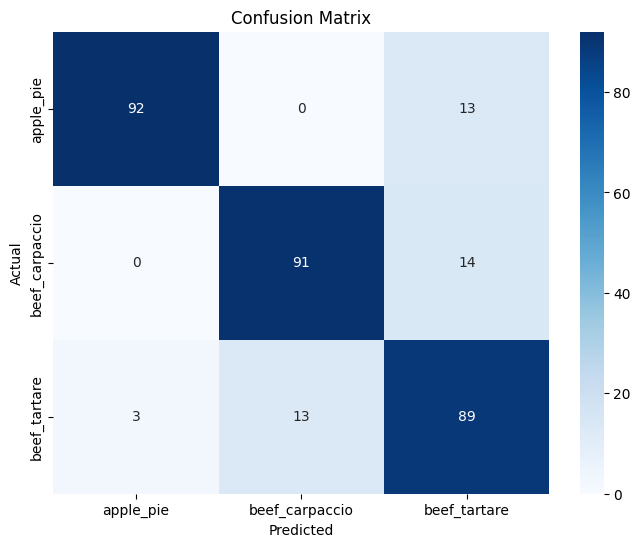

In [70]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ulangi untuk semua data test
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Classification report
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys(), cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

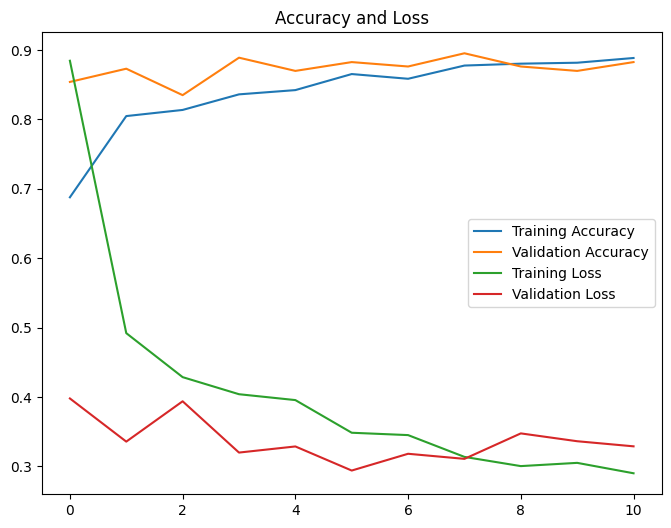

In [71]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 6))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Accuracy and Loss')
plt.show()

## Konversi Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [95]:
save_path = '/content/drive/MyDrive/model'
tf.saved_model.save(model, save_path)

In [96]:
import tensorflow as tf

# Konversi model ke format TF-Lite
# Changed from from_saved_model to from_keras_model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TF-Lite
with open('/content/drive/MyDrive/model/model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpf68damk_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140495778179280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778177360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778174096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778176784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778179088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778173520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778180816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778174480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778175440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140495778176208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1404957781810

In [87]:
!pip install tensorflowjs

In [99]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  "/content/drive/MyDrive/model" \
  "/content/drive/MyDrive/model/tfjs"

2025-05-13 15:32:11.733244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747150331.758075  179399 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747150331.765143  179399 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-05-13 15:32:16.762273: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1747150338.495142  179399 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00

In [1]:
# Menyimpan semua dependencies yang aktif saat ini
!pip freeze > requirements.txt

## Inference (Optional)